# 📊 Visualizações — Análise da Cana-de-Açúcar
## Fonte: CONAB — Companhia Nacional de Abastecimento

---

| | |
|---|---|
| 📅 **Safras** | 2017/18 a 2025/26 |
| 📊 **Fonte** | CONAB — Levantamentos Oficiais |
| 📈 **Notebook** | 03 — Visualizações e Gráficos |

---

> **Objetivo:** Gerar visualizações da evolução da produção, área plantada, qualidade (ATR)
> e derivados (açúcar e etanol) da cana-de-açúcar brasileira ao longo das safras,
> com foco em comparações regionais e tendências por estado (UF).

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import kaleido
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
from IPython.display import Image
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/cana_limpo.csv', encoding='utf-8')
df_all = pd.read_csv('../data/processed/cana_todos_levantamentos.csv', encoding='utf-8')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
print('Bibliotecas prontas!')

Bibliotecas prontas!


## 1. Produção total por safra

In [2]:
prod_safra = df.groupby('ano_agricola')['producao_mil_t'].sum().reset_index()

fig = px.bar(
    prod_safra, x='ano_agricola', y='producao_mil_t',
    title='Produção Total de Cana-de-Açúcar por Safra (mil t)',
    labels={'ano_agricola':'Safra','producao_mil_t':'Produção (mil t)'},
    color='producao_mil_t', color_continuous_scale='Greens',
    text_auto='.0f'
)
fig.update_layout(showlegend=False)
fig.show()
fig.write_image('../reports/figures/01_producao_por_safra.png', width=1000, height=500, scale=2)


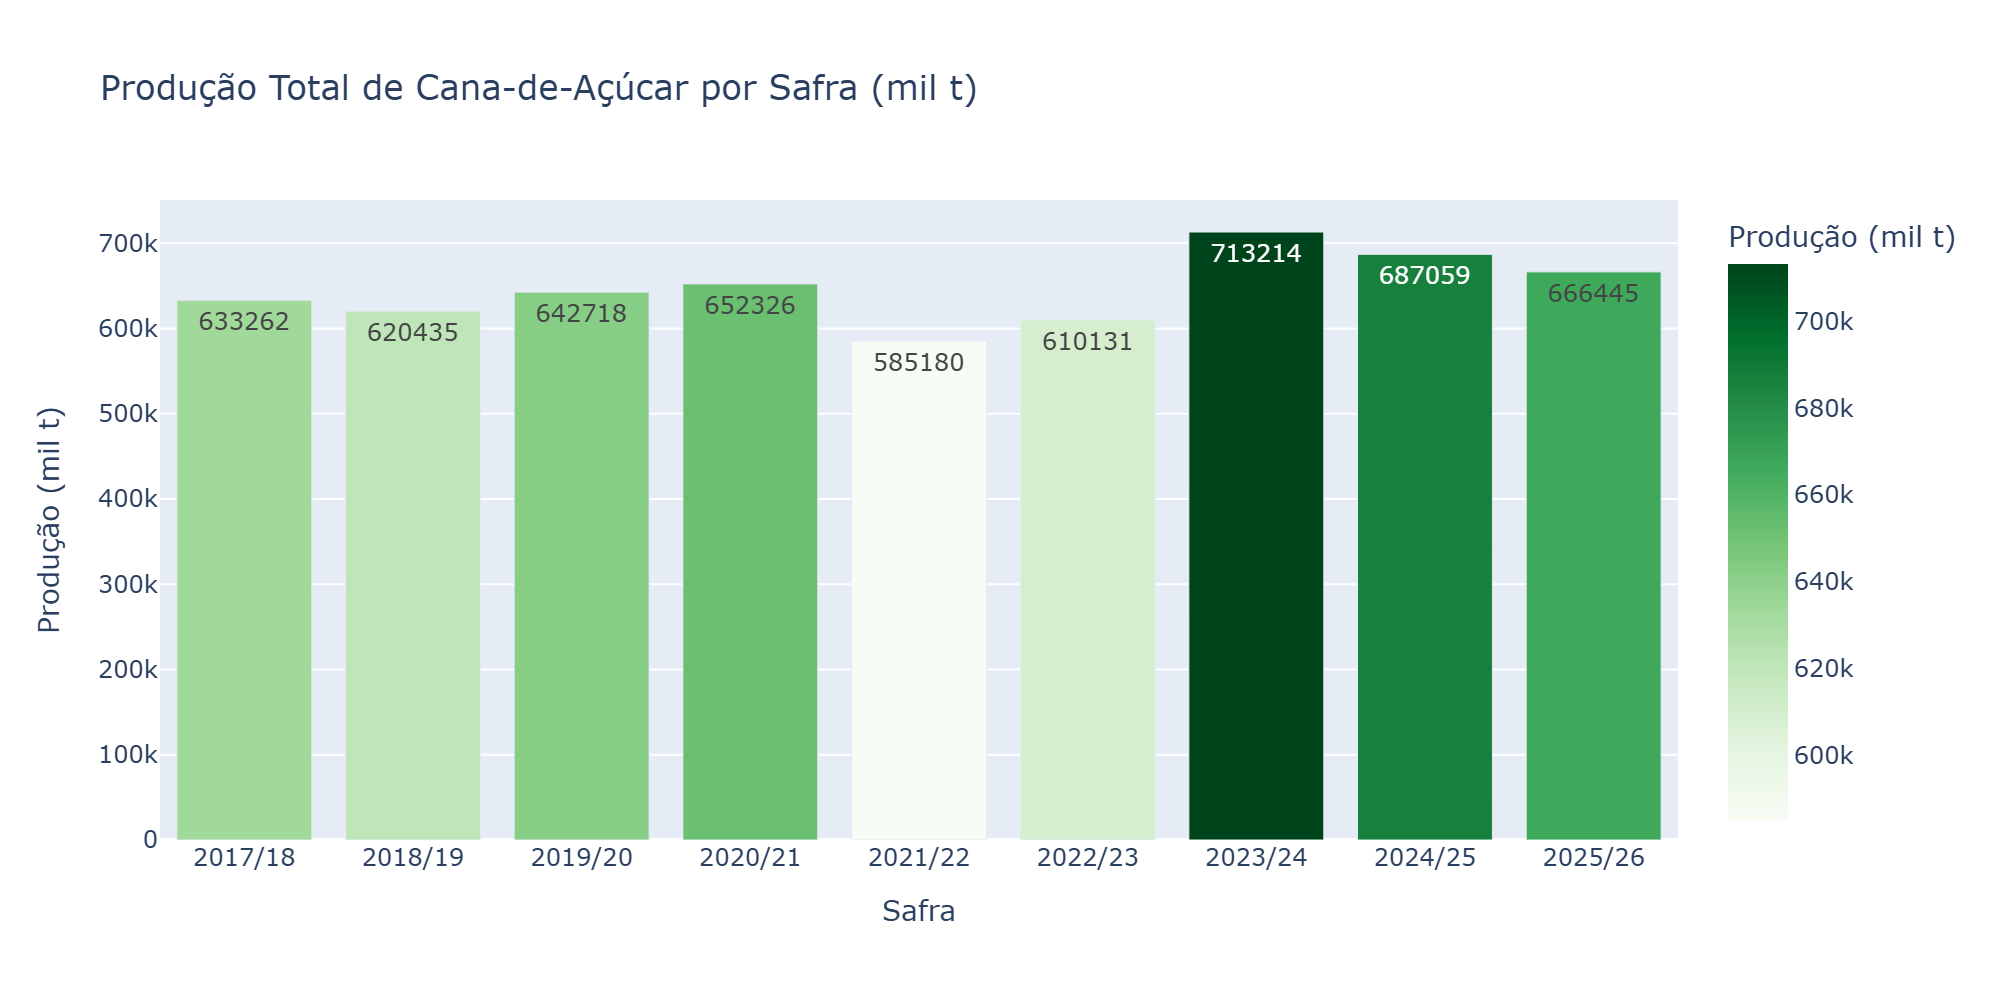

In [7]:
Image('../reports/figures/01_producao_por_safra.png', width=800)

### 📌 Insights — Produção Total por Safra

- **2023/24** registrou o **maior volume** do período: **713.214 mil t**, um crescimento de ~17% sobre a safra anterior
- **2021/22** foi o **pior ano** da série, com queda para **585.180 mil t** — reflexo de adversidades climáticas (geada + seca)
- Após a queda em 2021/22, o setor demonstrou **forte recuperação**, atingindo novo recorde em 2023/24
- A safra **2025/26** apresenta leve recuo em relação ao pico, mas mantém patamar **acima da média histórica**

> 💡 **Tendência geral:** crescimento consistente ao longo do período, com resiliência do setor mesmo após choques climáticos.

---

## 2. Top 10 estados produtores

In [6]:
top10 = df.groupby('uf')['producao_mil_t'].sum().nlargest(10).reset_index()

fig = px.bar(
    top10.sort_values('producao_mil_t'), x='producao_mil_t', y='uf',
    orientation='h',
    title='Top 10 Estados — Produção Acumulada de Cana (mil t)',
    labels={'uf':'Estado','producao_mil_t':'Produção acumulada (mil t)'},
    color='producao_mil_t', color_continuous_scale='YlGn'
)
fig.update_layout(showlegend=False)
fig.show()
fig.write_image('../reports/figures/02_top10_estados.png', width=1000, height=500, scale=2)

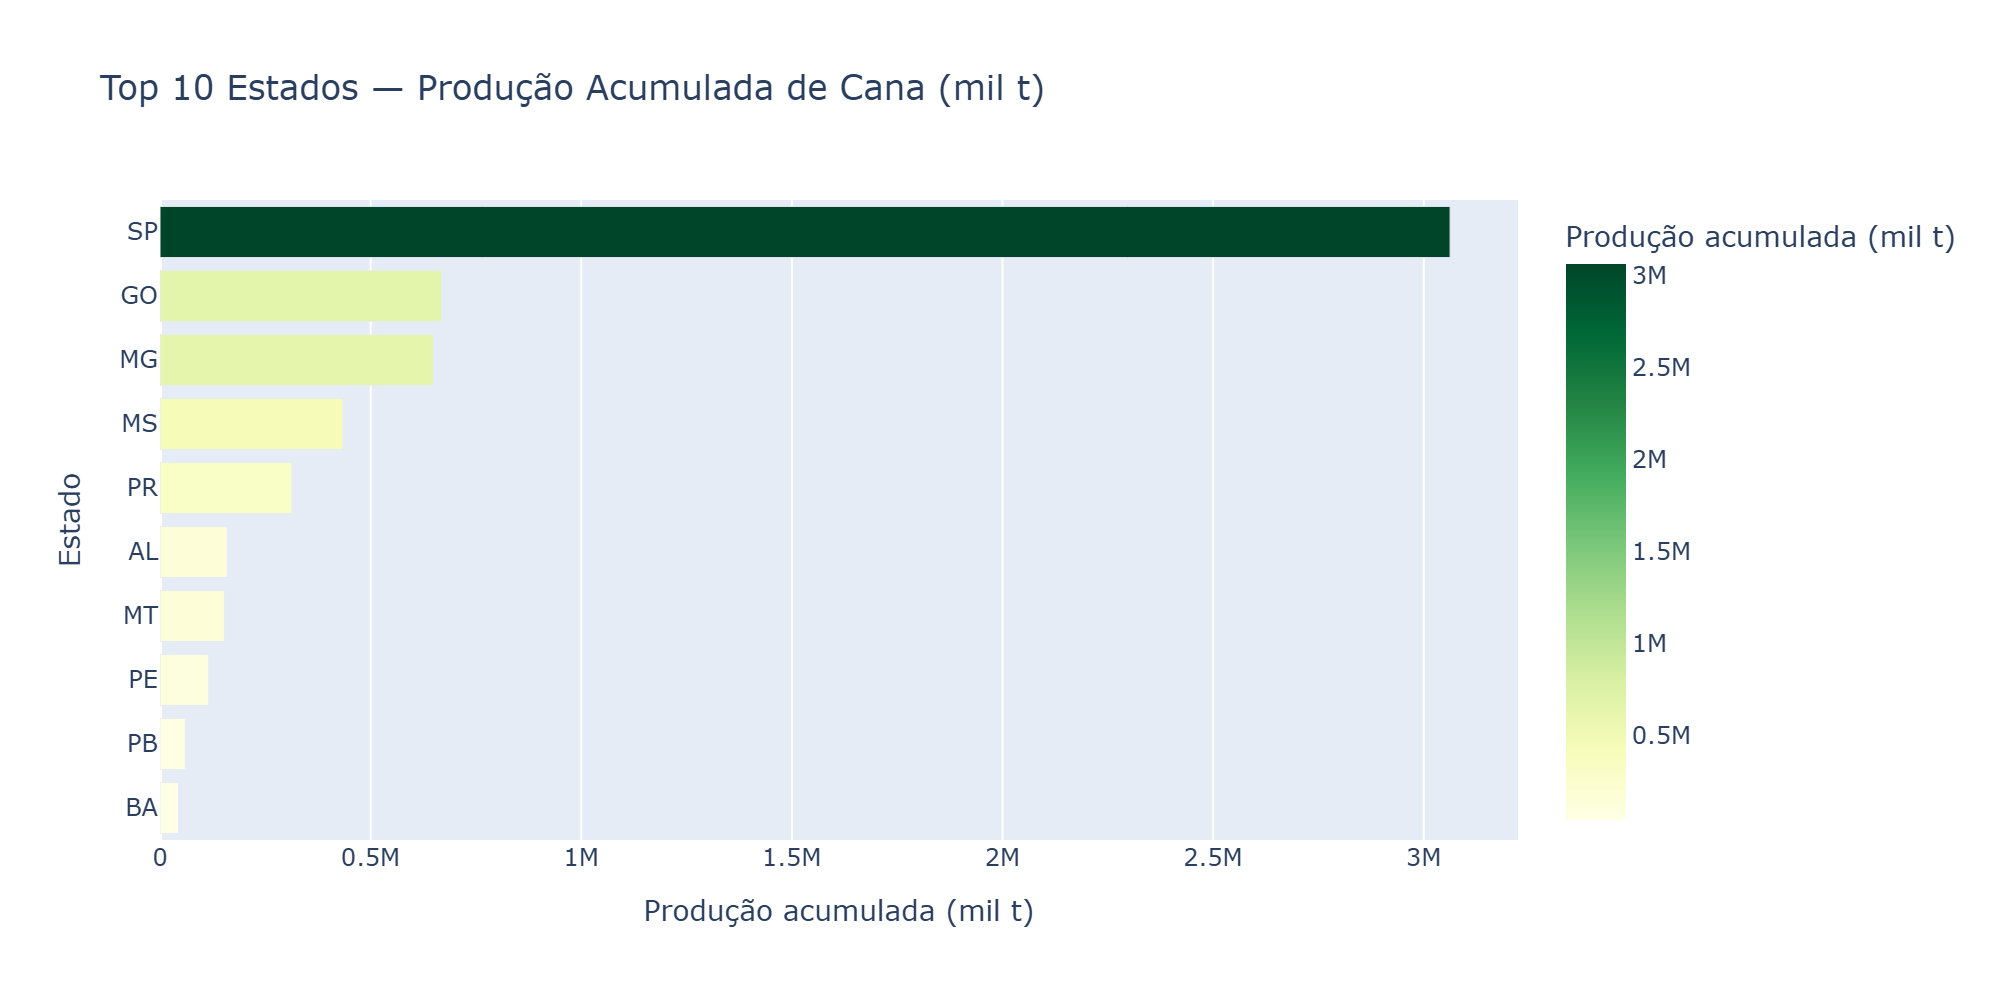

In [7]:
Image('../reports/figures/02_top10_estados.png', width=800)

### 📌 Insights — Produção Acumulada por Estado (UF)

- **SP** registrou a **maior produção acumulada** do ranking: **3.062.627,8 mil t**, representando sozinho mais de **58% do total** do Top 10
- **GO e MG** formam o **segundo bloco**, com 668.476,6 e 649.145,9 mil t respectivamente — produções similares entre si, porém **4,6x menores** que SP
- **MS e PR** ocupam a **faixa intermediária**, com 434.190,5 e 312.850,2 mil t — estados em expansão no Centro-Sul com crescente participação nacional
- **AL e PE** representam o **Nordeste** no ranking, com 159.828,2 e 115.789,3 mil t — presença histórica, mas com escala menor frente ao eixo Centro-Sul
- **MT, PB, BA e RN** fecham o Top 10 com produções abaixo de **153 mil t**, sinalizando participação ainda **incipiente no acumulado**

> 💡 **Tendência geral:** produção nacional fortemente concentrada no Centro-Sul, com SP como protagonista isolado — padrão que reflete décadas de expansão agroindustrial no estado.

---

## 3. Açúcar vs Etanol por safra

In [3]:
ae = df.groupby('ano_agricola').agg(
    acucar=('producao_acucar_mil_t','sum'),
    etanol=('producao_etanol_total_mil_l','sum')
).reset_index()
ae['etanol_mil_m3'] = (ae['etanol'] / 1_000_000).round(2)

fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_trace(go.Bar(x=ae['ano_agricola'], y=ae['acucar'], name='Açúcar (mil t)', marker_color='#f4a261'), secondary_y=False)
fig.add_trace(go.Scatter(x=ae['ano_agricola'], y=ae['etanol_mil_m3'], name='Etanol (bilhões L)', mode='lines+markers', line=dict(color='#2196F3', width=2)), secondary_y=True)
fig.update_layout(title='Produção de Açúcar e Etanol por Safra')
fig.update_yaxes(title_text='Açúcar (mil t)', secondary_y=False)
fig.update_yaxes(title_text='Etanol (bilhões L)', secondary_y=True)
fig.show()
fig.write_image('../reports/figures/03_acucar_vs_etanol.png', width=1000, height=500, scale=2)


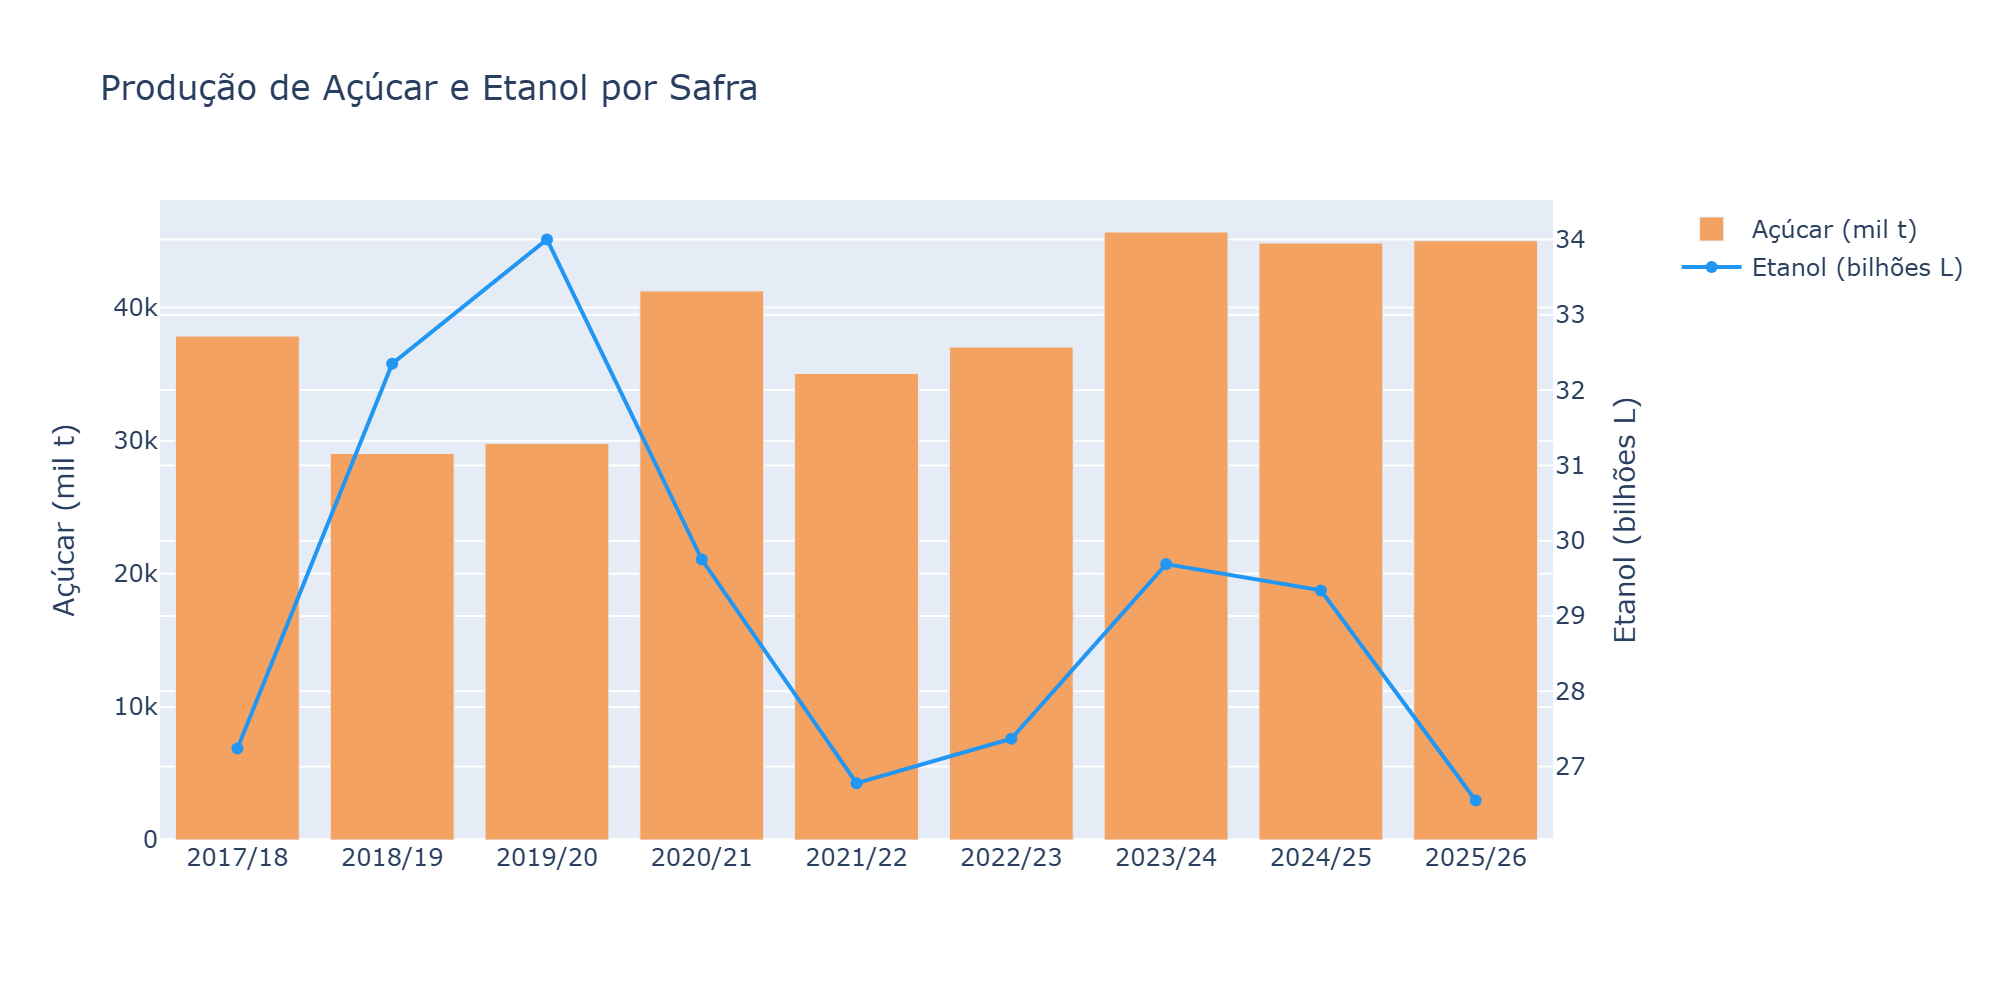

In [8]:
Image('../reports/figures/03_acucar_vs_etanol.png', width=800)

### 📌 Insights — Açúcar vs Etanol por Safra

- **2023/24** registrou o **pico histórico de açúcar**: **45.678,8 mil t** — maior volume das 8 safras, superando em +10,7% o segundo colocado (2024/25, 44.853,6 mil t), sinalizando dois anos consecutivos de recorde no segmento sólido
- **2019/20** concentrou a **máxima de etanol**: **34,00 bilhões de litros** — após a quebra de 2017/18 (27,24 bi L), o setor acelerou a conversão de cana para líquido, atingindo o topo do período analisado
- **2021/22 foi o piso duplo**: menor produção de açúcar (35.049,1 mil t) e de etanol (26,78 bi L) no ciclo — reflexo de adversidades climáticas e queda na disponibilidade de cana na região Centro-Sul
- A **proporção de cana para etanol oscilou entre 26,78% e 34,00%**, com média de ~29,8% — variação relativamente estreita, indicando que a flexibilidade produtiva das usinas (flex) absorve choques sem grandes desvios estruturais
- **Trajetória pós-2021/22**: ambos os indicadores se recuperam em conjunto, mas com dinâmicas distintas — açúcar em alta consistente (+30,3%), etanol em recuperação moderada (+9,6%), sugerindo **viés crescente de alocação para o sólido** nas safras recentes

> 💡 **Tendência geral:** o setor sucroenergético demonstra resiliência cíclica, com picos alternados entre açúcar e etanol conforme incentivos de preço — mas a aceleração pós-2022/23 no açúcar aponta para uma janela de rentabilidade que tem puxado a alocação produtiva para esse lado da balança.